In [1]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

In [4]:

# -------------------------------------------------
# Create Environment
# -------------------------------------------------
env = gym.make("FrozenLake-v1", is_slippery=False)

n_states = env.observation_space.n
n_actions = env.action_space.n



In [5]:

# -------------------------------------------------
# Hyperparameters
# -------------------------------------------------

num_episodes = 20000
gamma = 0.99
alpha = 0.1

epsilon_start = 1.0
epsilon_min = 0.05
epsilon_decay = 0.9995

max_steps_per_episode = 100



In [6]:
# -------------------------------------------------
# Initialize Q-table
# -------------------------------------------------
Q = np.zeros((n_states, n_actions))
returns_sum = {}
returns_count = {}

episode_rewards = []

# -------------------------------------------------
# Epsilon-Greedy Action Selection
# -------------------------------------------------
def epsilon_greedy_action(state, epsilon):
    if np.random.rand() < epsilon:
        return np.random.randint(n_actions)
    else:
        return np.argmax(Q[state])

In [7]:

# -------------------------------------------------
# Generate One Complete Episode
# -------------------------------------------------
def generate_episode(epsilon):
    episode = []

    state, _ = env.reset()

    for _ in range(max_steps_per_episode):
        action = epsilon_greedy_action(state, epsilon)

        next_state, reward, terminated, truncated, _ = env.step(action)

        episode.append((state, action, reward))

        state = next_state

        if terminated or truncated:
            break

    return episode


In [8]:
# -------------------------------------------------
# Monte Carlo Control (First-Visit)
# -------------------------------------------------
epsilon = epsilon_start

for episode_num in range(num_episodes):

    episode = generate_episode(epsilon)

    G = 0
    visited = set()
    total_reward = 0

    # Traverse episode backwards
    for t in reversed(range(len(episode))):
        state, action, reward = episode[t]
        G = gamma * G + reward
        total_reward += reward

        if (state, action) not in visited:
            visited.add((state, action))

            if (state, action) not in returns_sum:
                returns_sum[(state, action)] = 0
                returns_count[(state, action)] = 0

            returns_sum[(state, action)] += G
            returns_count[(state, action)] += 1

            Q[state][action] = returns_sum[(state, action)] / returns_count[(state, action)]

    episode_rewards.append(total_reward)

    # Decay epsilon
    epsilon = max(epsilon_min, epsilon * epsilon_decay)

In [9]:
# -------------------------------------------------
# Extract Greedy Policy
# -------------------------------------------------

optimal_policy = np.argmax(Q, axis=1)
state_values = np.max(Q, axis=1)


In [10]:
# -------------------------------------------------
# Display Results
# -------------------------------------------------

def print_policy(policy):
    action_symbols = {
        0: "L",
        1: "D",
        2: "R",
        3: "U"
    }

    policy_grid = np.array(
        [action_symbols[action] for action in policy]
    ).reshape(4, 4)
    print("Name:T MOUNISH")
    print("Register Number:212223240098")
    print("\nLearned Policy:")
    print(policy_grid)


def print_value_function(values):
    print("\nEstimated State-Value Function:")
    print(np.round(values.reshape(4, 4), 3))


print("\nFinal Q-table:")
print(np.round(Q, 3))

print_value_function(state_values)
print_policy(optimal_policy)

success_rate = np.mean(episode_rewards[-1000:])
print("\nAverage reward over last 1000 episodes:", success_rate)




Final Q-table:
[[0.43  0.825 0.406 0.46 ]
 [0.176 0.    0.565 0.174]
 [0.228 0.655 0.282 0.279]
 [0.388 0.    0.221 0.203]
 [0.498 0.869 0.    0.499]
 [0.    0.    0.    0.   ]
 [0.    0.867 0.    0.406]
 [0.    0.    0.    0.   ]
 [0.62  0.    0.91  0.543]
 [0.71  0.802 0.947 0.   ]
 [0.788 0.985 0.    0.738]
 [0.    0.    0.    0.   ]
 [0.    0.    0.    0.   ]
 [0.    0.607 0.957 0.459]
 [0.853 0.941 1.    0.874]
 [0.    0.    0.    0.   ]]

Estimated State-Value Function:
[[0.825 0.565 0.655 0.388]
 [0.869 0.    0.867 0.   ]
 [0.91  0.947 0.985 0.   ]
 [0.    0.957 1.    0.   ]]
Name:T MOUNISH
Register Number:212223240098

Learned Policy:
[['D' 'R' 'D' 'L']
 ['D' 'L' 'D' 'L']
 ['R' 'R' 'D' 'L']
 ['L' 'R' 'R' 'L']]

Average reward over last 1000 episodes: 0.953


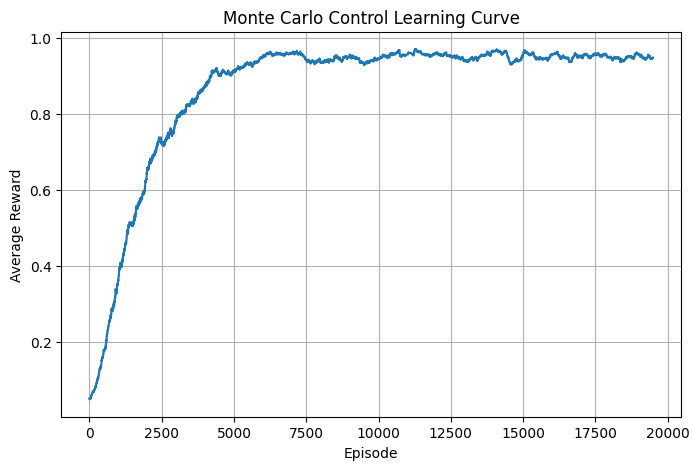

In [12]:
# -------------------------------------------------
# Plot Learning Curve
# -------------------------------------------------

window = 500
moving_average = np.convolve(
    episode_rewards,
    np.ones(window) / window,
    mode="valid"
)

plt.figure(figsize=(8, 5))
plt.plot(moving_average)
plt.xlabel("Episode")
plt.ylabel("Average Reward")
plt.title("Monte Carlo Control Learning Curve")
plt.grid(True)
plt.show()
env.close()

In [ ]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

In [ ]:

# -------------------------------------------------
# Create Environment
# -------------------------------------------------
env = gym.make("FrozenLake-v1", is_slippery=False)

n_states = env.observation_space.n
n_actions = env.action_space.n



In [ ]:

# -------------------------------------------------
# Hyperparameters
# -------------------------------------------------

num_episodes = 20000
gamma = 0.99
alpha = 0.1

epsilon_start = 1.0
epsilon_min = 0.05
epsilon_decay = 0.9995

max_steps_per_episode = 100



In [ ]:
# -------------------------------------------------
# Initialize Q-table
# -------------------------------------------------
Q = np.zeros((n_states, n_actions))
returns_sum = {}
returns_count = {}

episode_rewards = []

# -------------------------------------------------
# Epsilon-Greedy Action Selection
# -------------------------------------------------
def epsilon_greedy_action(state, epsilon):
    if np.random.rand() < epsilon:
        return np.random.randint(n_actions)
    else:
        return np.argmax(Q[state])

In [ ]:

# -------------------------------------------------
# Generate One Complete Episode
# -------------------------------------------------
def generate_episode(epsilon):
    episode = []

    state, _ = env.reset()

    for _ in range(max_steps_per_episode):
        action = epsilon_greedy_action(state, epsilon)

        next_state, reward, terminated, truncated, _ = env.step(action)

        episode.append((state, action, reward))

        state = next_state

        if terminated or truncated:
            break

    return episode


In [ ]:
# -------------------------------------------------
# Monte Carlo Control (First-Visit)
# -------------------------------------------------
epsilon = epsilon_start

for episode_num in range(num_episodes):

    episode = generate_episode(epsilon)

    G = 0
    visited = set()
    total_reward = 0

    # Traverse episode backwards
    for t in reversed(range(len(episode))):
        state, action, reward = episode[t]
        G = gamma * G + reward
        total_reward += reward

        if (state, action) not in visited:
            visited.add((state, action))

            if (state, action) not in returns_sum:
                returns_sum[(state, action)] = 0
                returns_count[(state, action)] = 0

            returns_sum[(state, action)] += G
            returns_count[(state, action)] += 1

            Q[state][action] = returns_sum[(state, action)] / returns_count[(state, action)]

    episode_rewards.append(total_reward)

    # Decay epsilon
    epsilon = max(epsilon_min, epsilon * epsilon_decay)

In [ ]:
# -------------------------------------------------
# Extract Greedy Policy
# -------------------------------------------------

optimal_policy = np.argmax(Q, axis=1)
state_values = np.max(Q, axis=1)


In [ ]:
# -------------------------------------------------
# Display Results
# -------------------------------------------------

def print_policy(policy):
    action_symbols = {
        0: "L",
        1: "D",
        2: "R",
        3: "U"
    }

    policy_grid = np.array(
        [action_symbols[action] for action in policy]
    ).reshape(4, 4)
    print("Name:T MOUNISH")
    print("Register Number:212223240098")
    print("\nLearned Policy:")
    print(policy_grid)


def print_value_function(values):
    print("\nEstimated State-Value Function:")
    print(np.round(values.reshape(4, 4), 3))


print("\nFinal Q-table:")
print(np.round(Q, 3))

print_value_function(state_values)
print_policy(optimal_policy)

success_rate = np.mean(episode_rewards[-1000:])
print("\nAverage reward over last 1000 episodes:", success_rate)




Final Q-table:
[[0.43  0.825 0.406 0.46 ]
 [0.176 0.    0.565 0.174]
 [0.228 0.655 0.282 0.279]
 [0.388 0.    0.221 0.203]
 [0.498 0.869 0.    0.499]
 [0.    0.    0.    0.   ]
 [0.    0.867 0.    0.406]
 [0.    0.    0.    0.   ]
 [0.62  0.    0.91  0.543]
 [0.71  0.802 0.947 0.   ]
 [0.788 0.985 0.    0.738]
 [0.    0.    0.    0.   ]
 [0.    0.    0.    0.   ]
 [0.    0.607 0.957 0.459]
 [0.853 0.941 1.    0.874]
 [0.    0.    0.    0.   ]]

Estimated State-Value Function:
[[0.825 0.565 0.655 0.388]
 [0.869 0.    0.867 0.   ]
 [0.91  0.947 0.985 0.   ]
 [0.    0.957 1.    0.   ]]
Name:T MOUNISH
Register Number:212223240098

Learned Policy:
[['D' 'R' 'D' 'L']
 ['D' 'L' 'D' 'L']
 ['R' 'R' 'D' 'L']
 ['L' 'R' 'R' 'L']]

Average reward over last 1000 episodes: 0.953


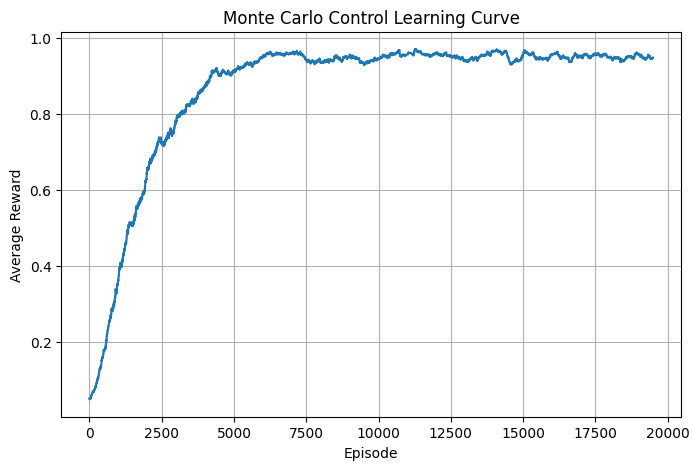

In [ ]:
# -------------------------------------------------
# Plot Learning Curve
# -------------------------------------------------

window = 500
moving_average = np.convolve(
    episode_rewards,
    np.ones(window) / window,
    mode="valid"
)

plt.figure(figsize=(8, 5))
plt.plot(moving_average)
plt.xlabel("Episode")
plt.ylabel("Average Reward")
plt.title("Monte Carlo Control Learning Curve")
plt.grid(True)
plt.show()
env.close()